In [4]:
import pandas as pd

train = pd.read_csv(r"C:/INTERNSHIP_ML&DA/Traffic/Project9/Project9_smart-city-traffic-patterns/Project9_smart-city-traffic-patterns/smart-city-traffic-patterns/train_aWnotuB.csv")

train.head()
print(train.describe())

           Junction      Vehicles            ID
count  48120.000000  48120.000000  4.812000e+04
mean       2.180549     22.791334  2.016330e+10
std        0.966955     20.750063  5.944854e+06
min        1.000000      1.000000  2.015110e+10
25%        1.000000      9.000000  2.016042e+10
50%        2.000000     15.000000  2.016093e+10
75%        3.000000     29.000000  2.017023e+10
max        4.000000    180.000000  2.017063e+10


In [5]:
#1 and 2 check size and datatype of data
print(train.head())

print(train.shape)

print(train.info())

print(train.isnull().sum())

print(train.describe())

              DateTime  Junction  Vehicles           ID
0  2015-11-01 00:00:00         1        15  20151101001
1  2015-11-01 01:00:00         1        13  20151101011
2  2015-11-01 02:00:00         1        10  20151101021
3  2015-11-01 03:00:00         1         7  20151101031
4  2015-11-01 04:00:00         1         9  20151101041
(48120, 4)
<class 'pandas.DataFrame'>
RangeIndex: 48120 entries, 0 to 48119
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   DateTime  48120 non-null  str  
 1   Junction  48120 non-null  int64
 2   Vehicles  48120 non-null  int64
 3   ID        48120 non-null  int64
dtypes: int64(3), str(1)
memory usage: 1.5 MB
None
DateTime    0
Junction    0
Vehicles    0
ID          0
dtype: int64
           Junction      Vehicles            ID
count  48120.000000  48120.000000  4.812000e+04
mean       2.180549     22.791334  2.016330e+10
std        0.966955     20.750063  5.944854e+06
min        1.000000   

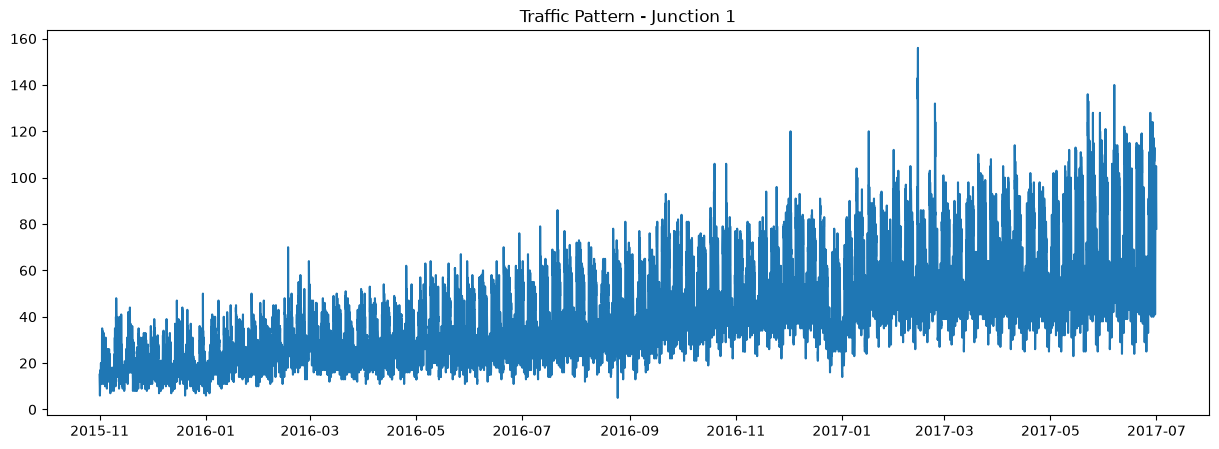

In [24]:
#12 plot individual junction traffic j1
j1 = train[train['Junction']==1]

plt.figure(figsize=(15,5))
plt.plot(j1['DateTime'], j1['Vehicles'])
plt.title("Traffic Pattern - Junction 1")
plt.show()

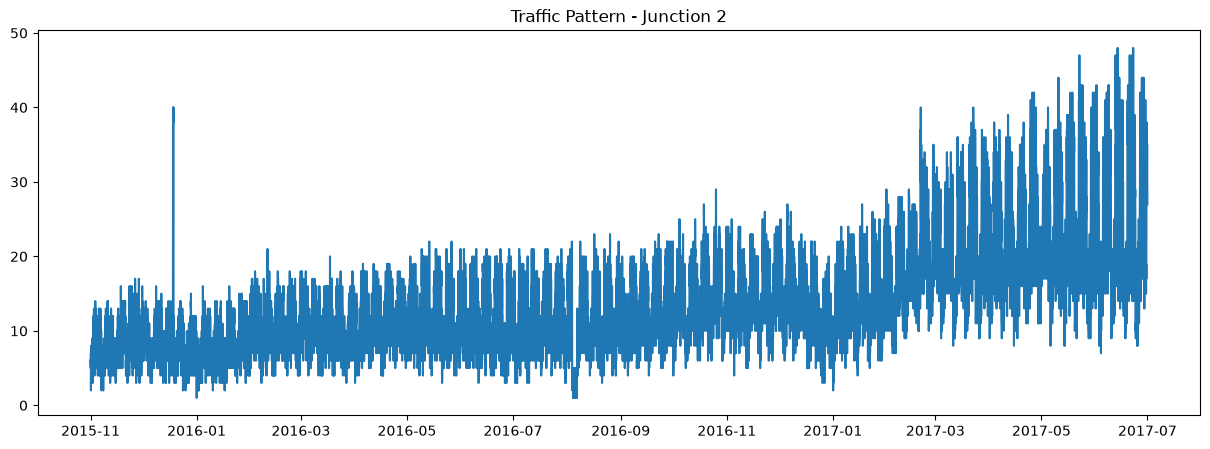

In [25]:
#12 plot individual junction traffic j2
j2 = train[train['Junction']==2]

plt.figure(figsize=(15,5))
plt.plot(j2['DateTime'], j2['Vehicles'])
plt.title("Traffic Pattern - Junction 2")
plt.show()

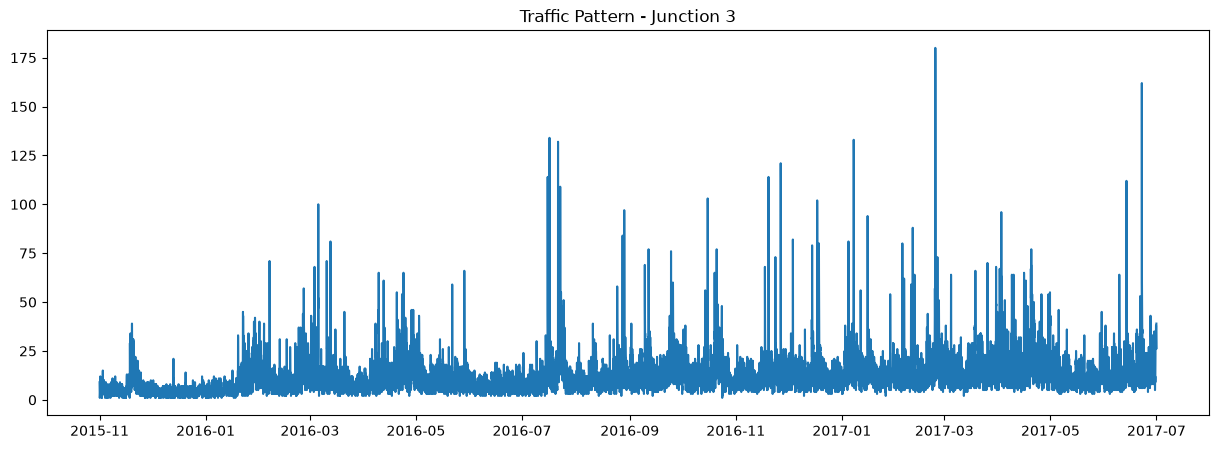

In [26]:
#12 plot individual junction traffic j3
j3 = train[train['Junction']==3]

plt.figure(figsize=(15,5))
plt.plot(j3['DateTime'], j3['Vehicles'])
plt.title("Traffic Pattern - Junction 3")
plt.show()

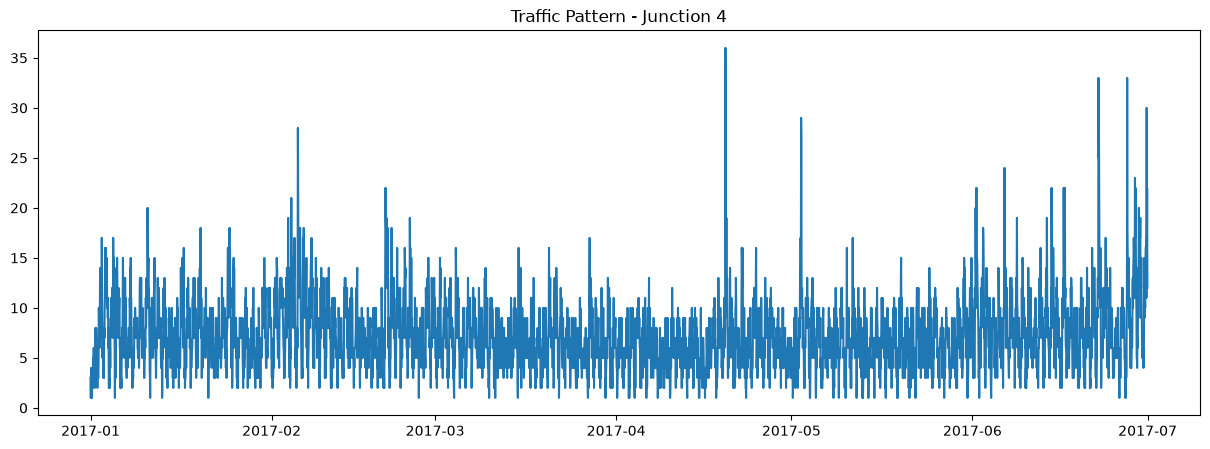

In [27]:
#12 plot individual junction traffic j4
j4 = train[train['Junction']==4]

plt.figure(figsize=(15,5))
plt.plot(j4['DateTime'], j4['Vehicles'])
plt.title("Traffic Pattern - Junction 4")
plt.show()

In [29]:
#13 create lag features
train = train.sort_values(['Junction','DateTime'])

train['Lag_1'] = train.groupby('Junction')['Vehicles'].shift(1)

train['Lag_24'] = train.groupby('Junction')['Vehicles'].shift(24)

train['Lag_168'] = train.groupby('Junction')['Vehicles'].shift(168)

In [30]:
#14 rolling averages
train['Rolling_24'] = (
    train.groupby('Junction')['Vehicles']
    .transform(lambda x: x.rolling(24).mean())
)

In [31]:
#15 remove generated nulls
train = train.dropna()

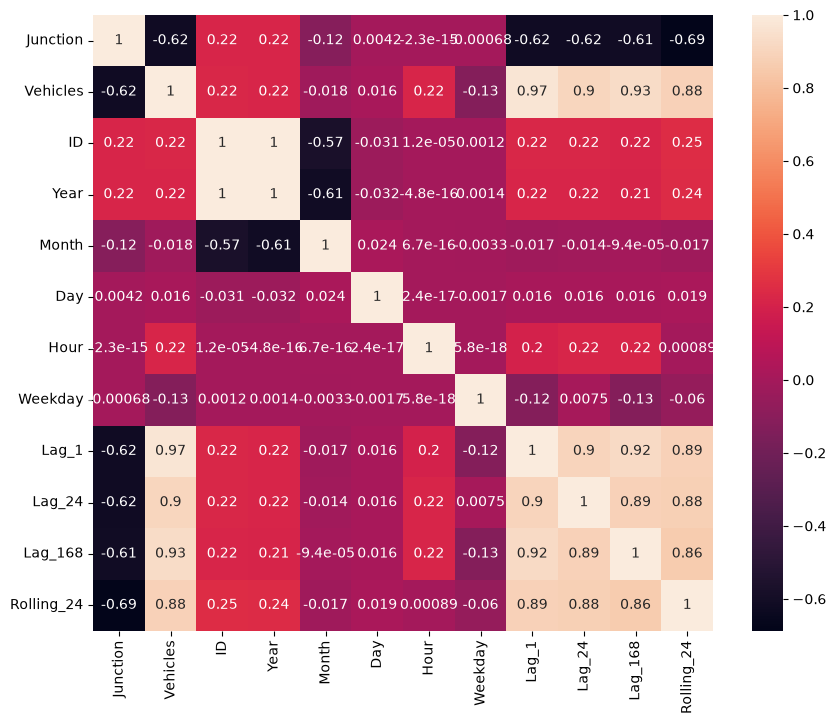

In [34]:
#16 correlation check
import seaborn as sns

corr = train.corr(numeric_only=True)

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True)
plt.show()

Junction
1    45.052906
2    14.253221
3    13.694010
4     7.251611
Name: Vehicles, dtype: float64


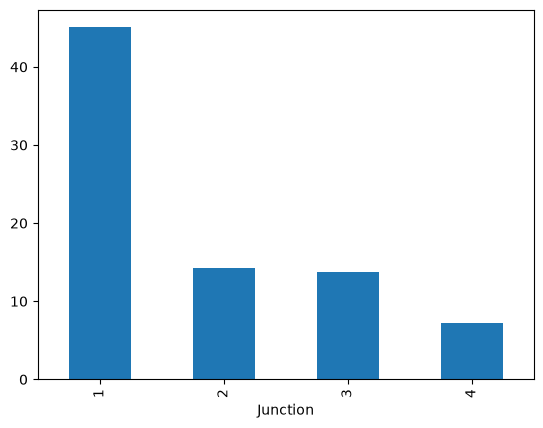

In [20]:
#analyze junctionwise traffic
junction_avg = train.groupby('Junction')['Vehicles'].mean()

print(junction_avg)

junction_avg.plot(kind='bar')
plt.show()

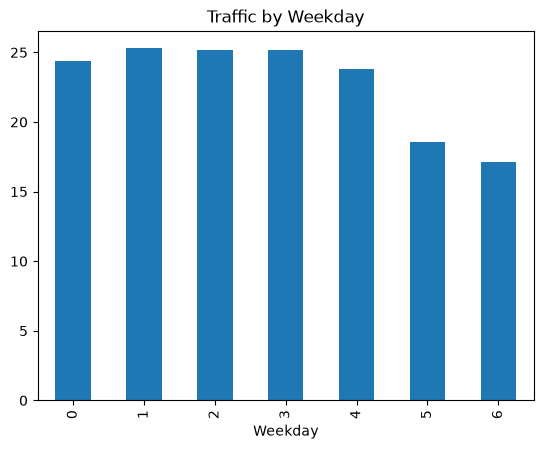

In [19]:
#step-10 analyze traffic by weekday
weekday = train.groupby('Weekday')['Vehicles'].mean()

weekday.plot(kind='bar')
plt.title("Traffic by Weekday")
plt.show()

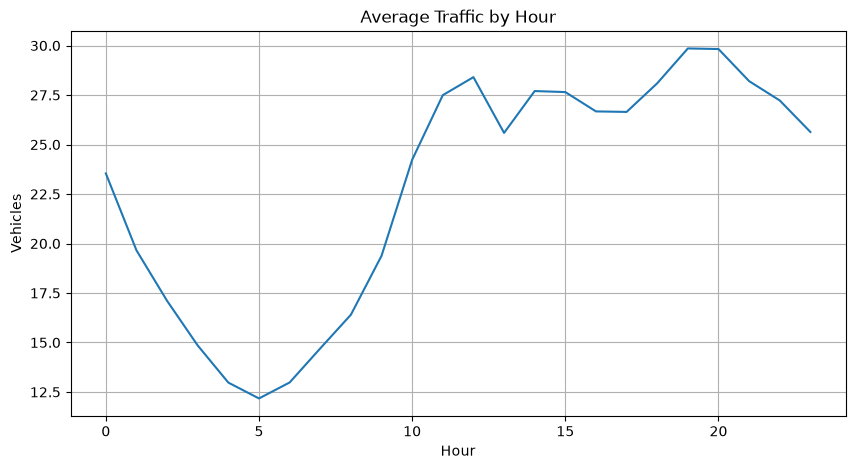

In [18]:
# step-9 analyze traffic by hr
import matplotlib.pyplot as plt

hourly = train.groupby('Hour')['Vehicles'].mean()

plt.figure(figsize=(10,5))
hourly.plot()
plt.title("Average Traffic by Hour")
plt.xlabel("Hour")
plt.ylabel("Vehicles")
plt.grid()
plt.show()

In [ ]:
#3.convert Datetime
train['DateTime'] = pd.to_datetime(train['DateTime'])
print(train.dtypes)

DateTime    datetime64[us]
Junction             int64
Vehicles             int64
ID                   int64
dtype: object


In [ ]:
#4.check missing values
train.isnull().sum()

DateTime    0
Junction    0
Vehicles    0
ID          0
dtype: int64

In [ ]:
#5.check no of junctions
train['Junction'].value_counts()

Junction
1    14592
2    14592
3    14592
4     4344
Name: count, dtype: int64

In [ ]:
#6.traffic stats
train['Vehicles'].describe()

count    48120.000000
mean        22.791334
std         20.750063
min          1.000000
25%          9.000000
50%         15.000000
75%         29.000000
max        180.000000
Name: Vehicles, dtype: float64

In [ ]:
#7.check time range
print(train['DateTime'].min())
print(train['DateTime'].max())

2015-11-01 00:00:00
2017-06-30 23:00:00


In [ ]:
#8 create time features
train['Year'] = train['DateTime'].dt.year
train['Month'] = train['DateTime'].dt.month
train['Day'] = train['DateTime'].dt.day
train['Hour'] = train['DateTime'].dt.hour
train['Weekday'] = train['DateTime'].dt.dayofweek

In [17]:
train.head()

,DateTime,Junction,Vehicles,ID,Year,Month,Day,Hour,Weekday
0,2015-11-01 00:00:00,1,15,20151101001,2015,11,1,0,6
1,2015-11-01 01:00:00,1,13,20151101011,2015,11,1,1,6
2,2015-11-01 02:00:00,1,10,20151101021,2015,11,1,2,6
3,2015-11-01 03:00:00,1,7,20151101031,2015,11,1,3,6
4,2015-11-01 04:00:00,1,9,20151101041,2015,11,1,4,6


In [3]:
!pip install seaborn

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached contourpy-1.3.3-cp313-cp313-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.63.0-cp313-cp313-win_amd64.whl.metadata (121 kB)
  Using cached kiwisolver-1.5.0-cp313-cp313-win_amd64.whl.metadata (5.2 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
   ---------------------------------------- 0.0/9.3 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.3 MB ? eta -:--:--
   --- ------------------------------------ 0.8/9.3 MB 2.0 MB/s eta 0:00:05
   ------- -------------------------------- 1.8/9.3 MB 2.8 MB/s eta 0:00:03
   ---------- ----------------------------- 2.4/9.3 MB 2.6 MB/s eta 0:00:03
   ------------ --------------------------- 2.9/9.3 MB 2.6 MB/s eta 0:00:03
   --------------- ------------------------ 3.7/9.3 MB 2.8 MB/s eta 0:00:03
   ---


[notice] A new release of pip is available: 25.2 -> 26.2
[notice] To update, run: python.exe -m pip install --upgrade pip


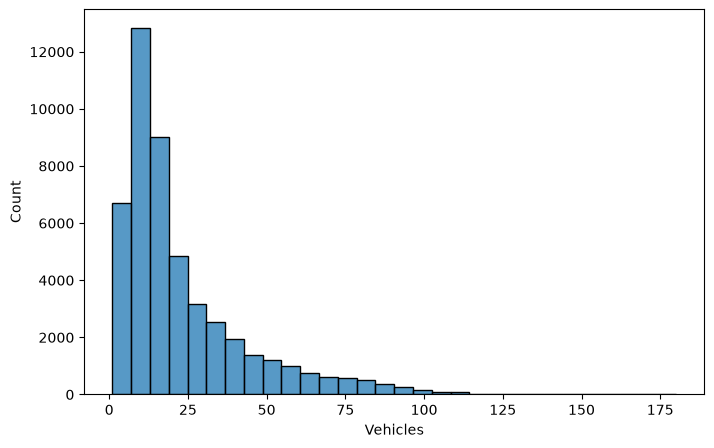

In [4]:
# traffic volume distribution
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))
sns.histplot(train['Vehicles'], bins=30)
plt.show()

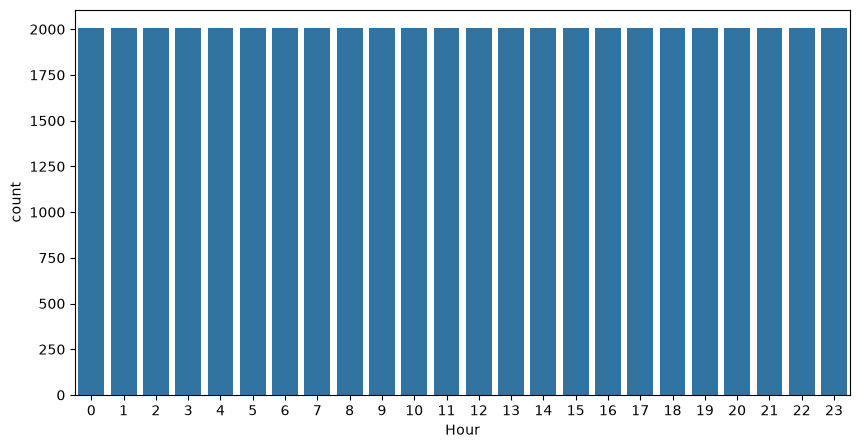

In [7]:
# Convert DateTime column into datetime format
train['DateTime'] = pd.to_datetime(train['DateTime'])

# Extract hour
train['Hour'] = train['DateTime'].dt.hour

# Plot peak hour analysis
plt.figure(figsize=(10,5))
sns.countplot(x='Hour', data=train)
plt.show()

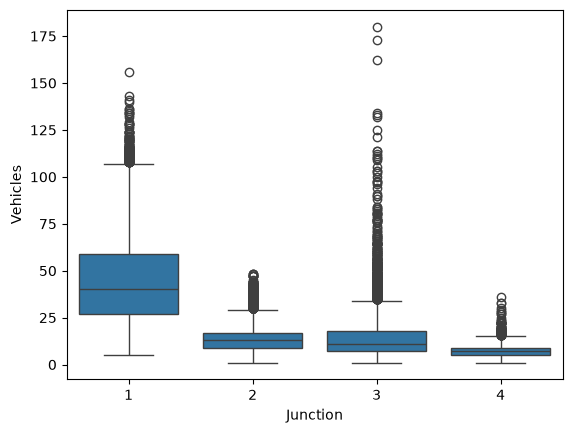

In [8]:
# traffic by junction
sns.boxplot(x='Junction', y='Vehicles', data=train)
plt.show()

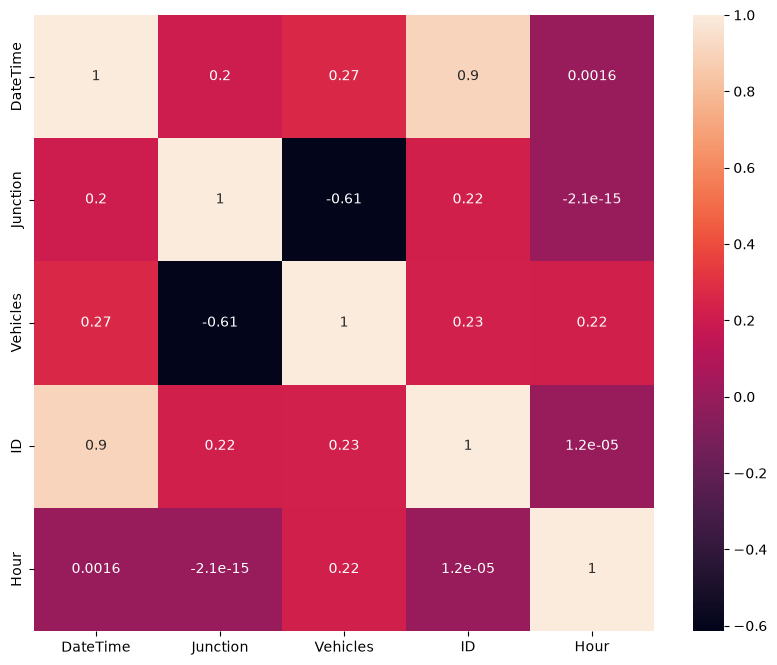

In [9]:
#corelation heatmap
plt.figure(figsize=(10,8))
sns.heatmap(train.corr(), annot=True)
plt.show()

In [10]:
#create weekend feature
df = train.copy()
df['Date'] = pd.to_datetime(df['DateTime'])
df['Day'] = df['Date'].dt.day_name()

df['Weekend'] = df['Day'].apply(lambda x: 1 if x in ['Saturday','Sunday'] else 0)

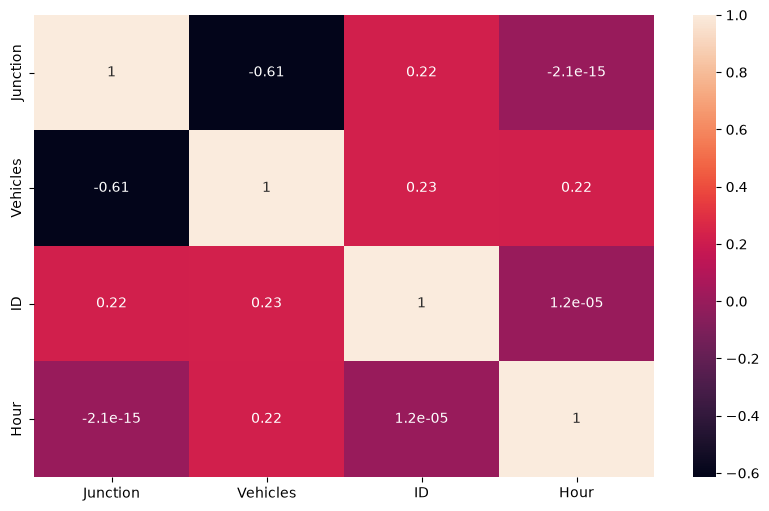

In [11]:
# week3 
# correlation heatmap
plt.figure(figsize=(10,6))
sns.heatmap(train.corr(numeric_only=True), annot=True)
plt.show()

In [12]:
#Day-wise Traffic Analysis
train['Day'] = train['DateTime'].dt.day_name()

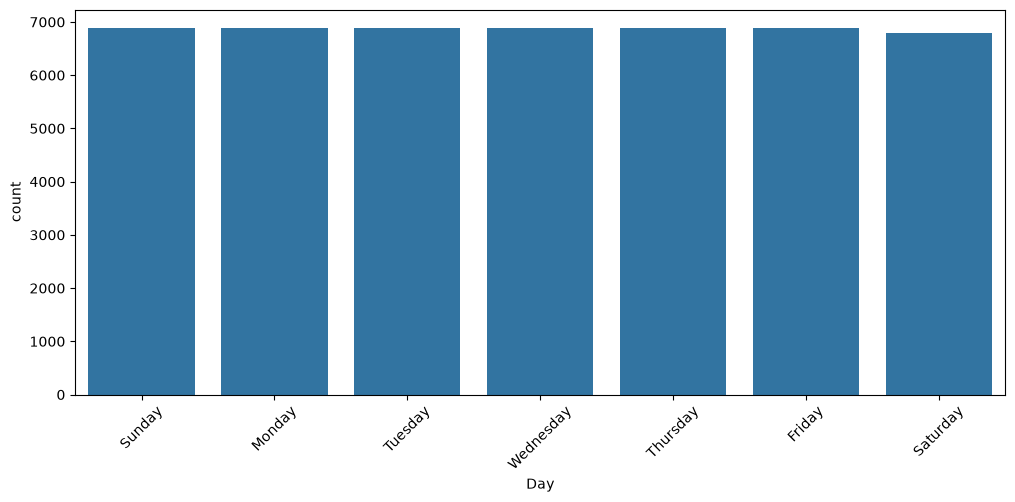

In [14]:
#plot
plt.figure(figsize=(12,5))
sns.countplot(x='Day', data=train)
plt.xticks(rotation=45)
plt.show()

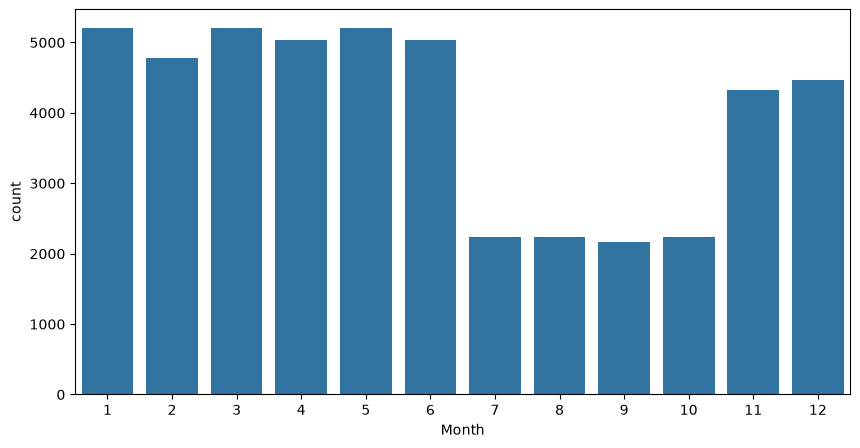

In [15]:
#Monthly Traffic Analysis
train['Month'] = train['DateTime'].dt.month

plt.figure(figsize=(10,5))
sns.countplot(x='Month', data=train)
plt.show()

In [16]:
#Create New Features (Feature Engineering)
train['Year'] = train['DateTime'].dt.year
train['Weekend'] = train['Day'].apply(lambda x: 1 if x in ['Saturday','Sunday'] else 0)

train['Peak_Hour'] = train['Hour'].apply(
    lambda x: 1 if (7 <= x <= 10) or (17 <= x <= 20) else 0
)

In [17]:
#feature selection
features = ['Junction', 'Hour', 'Month', 'Weekend', 'Peak_Hour']
X = train[features]
y = train['Vehicles']

In [18]:
#Convert categorical if needed
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
train['Junction'] = le.fit_transform(train['Junction'])

In [ ]:
print(train.isnull())

       DateTime  Junction  Vehicles     ID
0         False     False     False  False
1         False     False     False  False
2         False     False     False  False
3         False     False     False  False
4         False     False     False  False
...         ...       ...       ...    ...
48115     False     False     False  False
48116     False     False     False  False
48117     False     False     False  False
48118     False     False     False  False
48119     False     False     False  False

[48120 rows x 4 columns]


: 

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:

train = pd.read_csv(r"C:/INTERNSHIP_ML&DA/Traffic/Project9/Project9_smart-city-traffic-patterns/Project9_smart-city-traffic-patterns/smart-city-traffic-patterns/train_aWnotuB.csv")
train

,DateTime,Junction,Vehicles,ID
0,2015-11-01 00:00:00,1,15,20151101001
1,2015-11-01 01:00:00,1,13,20151101011
2,2015-11-01 02:00:00,1,10,20151101021
3,2015-11-01 03:00:00,1,7,20151101031
4,2015-11-01 04:00:00,1,9,20151101041
...,...,...,...,...
48115,2017-06-30 19:00:00,4,11,20170630194
48116,2017-06-30 20:00:00,4,30,20170630204
48117,2017-06-30 21:00:00,4,16,20170630214
48118,2017-06-30 22:00:00,4,22,20170630224


In [6]:
train.shape

(48120, 4)

In [11]:
train.info

<bound method DataFrame.info of                   DateTime  Junction  Vehicles           ID
0      2015-11-01 00:00:00         1        15  20151101001
1      2015-11-01 01:00:00         1        13  20151101011
2      2015-11-01 02:00:00         1        10  20151101021
3      2015-11-01 03:00:00         1         7  20151101031
4      2015-11-01 04:00:00         1         9  20151101041
...                    ...       ...       ...          ...
48115  2017-06-30 19:00:00         4        11  20170630194
48116  2017-06-30 20:00:00         4        30  20170630204
48117  2017-06-30 21:00:00         4        16  20170630214
48118  2017-06-30 22:00:00         4        22  20170630224
48119  2017-06-30 23:00:00         4        12  20170630234

[48120 rows x 4 columns]>

In [7]:
train.head(10)

,DateTime,Junction,Vehicles,ID
0,2015-11-01 00:00:00,1,15,20151101001
1,2015-11-01 01:00:00,1,13,20151101011
2,2015-11-01 02:00:00,1,10,20151101021
3,2015-11-01 03:00:00,1,7,20151101031
4,2015-11-01 04:00:00,1,9,20151101041
5,2015-11-01 05:00:00,1,6,20151101051
6,2015-11-01 06:00:00,1,9,20151101061
7,2015-11-01 07:00:00,1,8,20151101071
8,2015-11-01 08:00:00,1,11,20151101081
9,2015-11-01 09:00:00,1,12,20151101091


In [8]:
train.tail(10)

,DateTime,Junction,Vehicles,ID
48110,2017-06-30 14:00:00,4,10,20170630144
48111,2017-06-30 15:00:00,4,14,20170630154
48112,2017-06-30 16:00:00,4,16,20170630164
48113,2017-06-30 17:00:00,4,16,20170630174
48114,2017-06-30 18:00:00,4,17,20170630184
48115,2017-06-30 19:00:00,4,11,20170630194
48116,2017-06-30 20:00:00,4,30,20170630204
48117,2017-06-30 21:00:00,4,16,20170630214
48118,2017-06-30 22:00:00,4,22,20170630224
48119,2017-06-30 23:00:00,4,12,20170630234


In [9]:
train.describe

<bound method NDFrame.describe of                   DateTime  Junction  Vehicles           ID
0      2015-11-01 00:00:00         1        15  20151101001
1      2015-11-01 01:00:00         1        13  20151101011
2      2015-11-01 02:00:00         1        10  20151101021
3      2015-11-01 03:00:00         1         7  20151101031
4      2015-11-01 04:00:00         1         9  20151101041
...                    ...       ...       ...          ...
48115  2017-06-30 19:00:00         4        11  20170630194
48116  2017-06-30 20:00:00         4        30  20170630204
48117  2017-06-30 21:00:00         4        16  20170630214
48118  2017-06-30 22:00:00         4        22  20170630224
48119  2017-06-30 23:00:00         4        12  20170630234

[48120 rows x 4 columns]>

In [24]:
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder
label=LabelEncoder()
train['Junction']=label.fit_transform(train['Junction'])
encoder=OneHotEncoder()
train=encoder.fit_transform(train[['Junction']])


IndexError: Index dimension must be 1 or 2. Got 0

In [16]:
!pip install scikit-learn

  Using cached scikit_learn-1.9.0-cp313-cp313-win_amd64.whl.metadata (11 kB)
  Using cached scipy-1.18.0-cp313-cp313-win_amd64.whl.metadata (61 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
Using cached scikit_learn-1.9.0-cp313-cp313-win_amd64.whl (8.2 MB)
Using cached joblib-1.5.3-py3-none-any.whl (309 kB)
Using cached scipy-1.18.0-cp313-cp313-win_amd64.whl (36.6 MB)
Using cached threadpoolctl-3.6.0-py3-none-any.whl (18 kB)

   -------- ------------------------------- 1/5 [scipy]
   -------- ------------------------------- 1/5 [scipy]
   -------- ------------------------------- 1/5 [scipy]
   -------- ------------------------------- 1/5 [scipy]
   -------- ------------------------------- 1/5 [scipy]
   -------- ------------------------------- 1/5 [scipy]
   -------- ------------------------------- 1/5 [scipy]
   -------- ------------------------------- 1/5 [scipy]
   -------- --------------------


[notice] A new release of pip is available: 25.2 -> 26.2
[notice] To update, run: python.exe -m pip install --upgrade pip
